In [1]:
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage
from matplotlib.lines import Line2D
from scipy.spatial.distance import pdist

In [2]:
filtered_embeddings_path = Path('.') / 'filtered_embeddings' / 'd2v_poem_d100_w5_dbow.npy'

arr = np.load(filtered_embeddings_path).astype(np.float64)
norms = np.linalg.norm(arr, axis=1, keepdims=True)
norms[norms == 0] = 1.0
embeddings = arr / norms

metadata = pd.read_csv(Path('.') / 'filtered_poems.csv', engine='python')

print(f'Embeddings: {len(embeddings)}')

Embeddings: 2853


# Filter some embeddings for dendrogram visualization

In [3]:
top_20_poets = metadata['Poet'].value_counts().head(30).index
top_20_poets

Index(['Alfred, Lord Tennyson', 'William Wordsworth', 'William Shakespeare',
       'Emily Dickinson', 'John Ashbery', 'William Blake', 'John Milton',
       'Rae Armantrout', 'John Donne', 'Percy Bysshe Shelley',
       'Algernon Charles Swinburne', 'Thomas Hardy', 'Edmund Spenser',
       'Robert Browning', 'Walt Whitman', 'Yusef Komunyakaa',
       'Edgar Lee Masters', 'Henry Wadsworth Longfellow',
       'Samuel Taylor Coleridge', 'Edward Thomas', 'W. S. Di Piero',
       'Dean Young', 'W. S. Merwin', 'Elizabeth Barrett Browning',
       'Edna St. Vincent Millay', 'Robert Frost', 'Amy Lowell',
       'Carl Sandburg', 'Sir  Thomas Wyatt', 'Matthew Arnold'],
      dtype='object', name='Poet')

In [4]:
poets = [
    "William Shakespeare",
    "John Milton",
    "Percy Bysshe Shelley",
    "Henry Wadsworth Longfellow",
    "W. S. Di Piero",
    "John Ashbery"
]

poets_abbrev = {
    "William Shakespeare" : "Shakespeare",
    "John Milton": "Milton",
    "Percy Bysshe Shelley": "Shelley",
    "Henry Wadsworth Longfellow": "Longfellow",
    "W. S. Di Piero": "Di Piero",
    "John Ashbery": "Ashbery"
}

# Filter only the poets of interest
filtered_md = metadata[metadata["Poet"].isin(poets)]

sampled_md = filtered_md.groupby("Poet", group_keys=False).head(2)

sampled_md = sampled_md.sort_index()
sampled_md

,Title,Poet,Poem,Tags,Emotion,PoetBirth,Period,Format
66,from At a Vacation Exercise,John Milton,"Hail native language, that by sinews weak Dids...","Arts & Sciences,Poetry & Poets",Anger,1608.0,1550-1780,ll-sp
67,Paradise Lost: Book 2 (1674 version),John Milton,"HIgh on a Throne of Royal State, which far Out...","Religion,Christianity,God & the Divine",Joy,1608.0,1550-1780,ll-sp
236,"Sonnet 123: No, Time, thou shalt not boast tha...",William Shakespeare,"No, Time, thou shalt not boast that I do chang...","Living,Time & Brevity,Arts & Sciences",Fear,1564.0,1550-1780,ll-sp
237,Sonnet 133: Beshrew that heart that makes my h...,William Shakespeare,Beshrew that heart that makes my heart to groa...,"Love,Break-ups & Vexed Love,Unrequited Love,So...",Sadness,1564.0,1550-1780,ll-sp
259,from Laon and Cythna; or The Revolution of the...,Percy Bysshe Shelley,To Mary — —\r\r\n\r\r\n\r\r\n\r\r\n ...,"Love,Romantic Love,Nature,Seas, Rivers, & Stre...",Fear,1792.0,1781-1900,ll-sp
285,Wet Casements,John Ashbery,"When Eduard Raban, coming along the passage, w...","Love,Infatuation & Crushes,Relationships,Frien...",Surprise,1927.0,1941-1970,sl-lp
386,The Three Kings,Henry Wadsworth Longfellow,"Three Kings came riding from far away, Melchio...",Christmas,Joy,1807.0,1781-1900,ll-sp
615,Injun Joe as an Avatar,W. S. Di Piero,"The poetry’s arrested in his scene,which can’t...","Arts & Sciences,Poetry & Poets",Fear,1945.0,1941-1970,ll-sp
616,What’s Left,W. S. Di Piero,"How often now, raging weeping for the dayslove...","Love,Heartache & Loss",Love,1945.0,1941-1970,ll-sp
737,This Room,John Ashbery,The room I entered was a dream of this room....,"Activities,Eating & Drinking,Indoor Activities...",Fear,1927.0,1941-1970,sl-sp


In [5]:
selected_indices = sampled_md.index.to_numpy()
filtered_embeddings = embeddings[selected_indices]
filtered_embeddings.shape

(12, 100)

In [7]:
# cosine distance matrix
distance_matrix = pdist(filtered_embeddings, metric='cosine')

# hierarchical clustering
Z = linkage(distance_matrix, method='average')

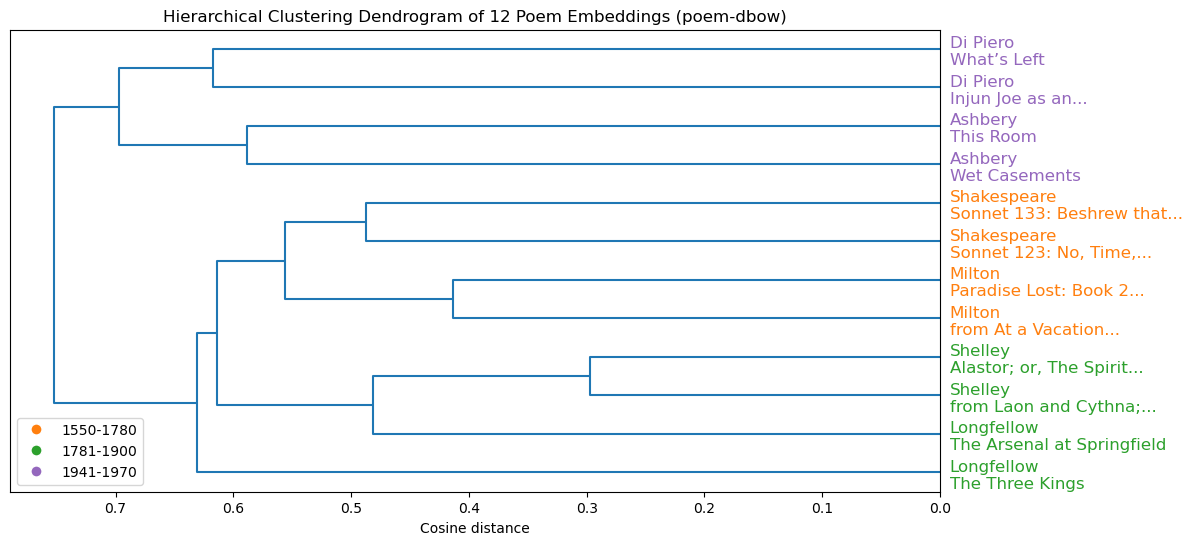

In [8]:


era_colors = {
    "1550-1780": "tab:orange",
    "1781-1900": "tab:green",
    "1941-1970": "tab:purple"
}

plt.figure(figsize=(12, 6))
title_words = sampled_md["Title"].str.split()

labels = sampled_md["Poet"].map(poets_abbrev) + "\n" + title_words.str[:4].str.join(" ") + title_words.apply(lambda x: "..." if len(x) > 4 else "")
eras = sampled_md["Period"]
label_to_era = dict(zip(labels, eras))

dendro = dendrogram(
    Z,
    labels=labels.to_numpy(),
    color_threshold = 0,
    orientation="left" 
)

ax = plt.gca()

yticklabels = ax.get_ymajorticklabels()

for tick in yticklabels:
    label = tick.get_text()
    era = label_to_era.get(label, None)
    if era:
        tick.set_color(era_colors.get(era, "black"))

legend_handles = [
    Line2D([0], [0], marker='o', color='w',
           label=era,
           markerfacecolor=color,
           markersize=8)
    for era, color in era_colors.items()
]

plt.title("Hierarchical Clustering Dendrogram of 12 Poem Embeddings (poem-dbow)")
plt.xlabel("Cosine distance")
plt.legend(
    handles=legend_handles,
    loc="lower left"
)
plt.savefig("figures/fig_dendrogram.png", bbox_inches="tight")
plt.show()